In [1]:
from torchvision.datasets import FashionMNIST
from typing import Dict, Tuple
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np
from IPython.display import HTML

## Utils

In [2]:
def unorm(x):
  return (x - x.min()) / (x.max() - x.min())

In [3]:
def plot_sample(samples, n_sample, nrows):
    ncols = n_sample//nrows
    samples = unorm(samples.cpu())
    # Create a figure with subplots
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 10))

    # Flatten the axes array for easy iteration
    axes = axes.flatten()

    # Loop through each image and plot it
    for i in range(n_sample):
        # Select image
        image = samples[i]

        # Handle grayscale (1 channel) vs RGB (3 channels)
        if image.shape[0] == 1:
            image = image.squeeze(0)
            axes[i].imshow(image, cmap='gray')
        else:
            image = image.permute(1, 2, 0)
            axes[i].imshow(image)

        axes[i].axis('off')  # Hide axis
        axes[i].set_title(f'Image {i + 1}')  # Set title

    # Hide any unused subplots
    for j in range(n_sample, nrows * ncols):
        axes[j].axis('off')

    # Adjust layout
    plt.tight_layout()
    plt.show()

## hyperparameters


In [26]:
# diffusion hyperparameters
timesteps = 1000
beta1 = 1e-4
beta2 = 0.02

# network hyperparameters
device = torch.device("cuda:0" if torch.cuda.is_available() else torch.device('cpu'))
n_feat = 64 # 64 hidden dimension feature
n_cfeat = 10 # context vector is of size 10 (FashionMNIST classes)
height = 32 # 32x32 image
save_dir = '/content/'

# training hyperparameters
batch_size = 128
n_epoch = 40 # Reduced for T4 quick testing if needed, or keep 40. 20 is prob fine.
lrate = 5e-4

## FashionMNIST Dataset

In [5]:
# FashionMNIST download handled by torchvision

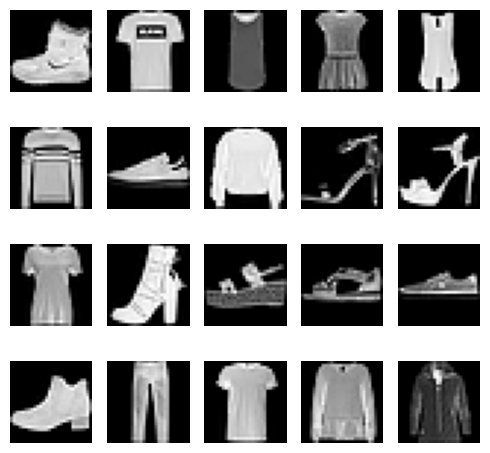

In [5]:
# Download and visualize a few FashionMNIST samples
temp_dataset = FashionMNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
fig, axes = plt.subplots(4, 5, figsize=(5, 5))
axes = axes.flatten()
for i in range(20):
    img, label = temp_dataset[i]
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [6]:
transform = transforms.Compose([
    transforms.Resize((height, height)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [7]:
train_dataset = FashionMNIST(root='./data', train=True, download=True, transform=transform)
val_dataset = FashionMNIST(root='./data', train=False, download=True, transform=transform)

# For testing on a smaller subset if needed, otherwise use full
# train_dataset = torch.utils.data.Subset(train_dataset, range(1000))


In [8]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

## UNet

So what model do we use to do this magical 'denoising' step? We've looked a little at basic convolutional neural networks that take in an image and output something like a classification. And we've seen autoencoders that go from an image down to a latent representation and back to an output image. Perhaps one of these would be suitable?

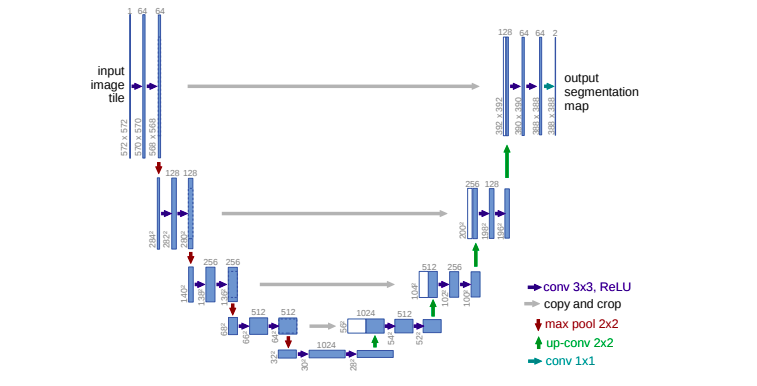

(Unet diagram from [the 2015 paper](https://arxiv.org/abs/1505.04597))

One issue with a typical 'bottlekneck' architecture like an autoencoder is that by design they loose the details around exact pixel coordinates. To get around this, an architecture called the Unet was introduced. Originally designed for segmentation tasks, the architecture (shown above) passes information from high-resolution, early layers to later layers. These 'shortcuts' let the network use detailed features from the original image while also capturing more high-level semantic information from the deeper layers.

These networks turned out to be great at all sorts of image-to-image tasks. Colorization , segmentation and so on. These days, typical unet models incorporate ideas such as attention and can be built around pretrained 'backbones' like resnet-50 for transfer learning tasks.

The implementation below is a fairly typical modern Unet with one extra trick: a TimeEmbedding which encodes the time step (t) and lets the model use this as conditioning information by passing it in in the middle of the network. Take a peek at the code and see if you can figure out roughly what's going on in the forward pass.



In [9]:
class ResidualConvBlock(nn.Module):
    def __init__(
        self, in_channels: int, out_channels: int, is_res: bool = False
    ) -> None:
        super().__init__()

        # Check if input and output channels are the same for the residual connection
        self.same_channels = in_channels == out_channels

        # Flag for whether or not to use residual connection
        self.is_res = is_res

        # First convolutional layer
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1),   # 3x3 kernel with stride 1 and padding 1
            nn.BatchNorm2d(out_channels),   # Batch normalization
            nn.GELU(),   # GELU activation function
        )

        # Second convolutional layer
        self.conv2 = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, 3, 1, 1),   # 3x3 kernel with stride 1 and padding 1
            nn.BatchNorm2d(out_channels),   # Batch normalization
            nn.GELU(),   # GELU activation function
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        # If using residual connection
        if self.is_res:
            # Apply first convolutional layer
            x1 = self.conv1(x)

            # Apply second convolutional layer
            x2 = self.conv2(x1)

            # If input and output channels are the same, add residual connection directly
            if self.same_channels:
                out = x + x2
            else:
                # If not, apply a 1x1 convolutional layer to match dimensions before adding residual connection
                shortcut = nn.Conv2d(x.shape[1], x2.shape[1], kernel_size=1, stride=1, padding=0).to(x.device)
                out = shortcut(x) + x2
            #print(f"resconv forward: x {x.shape}, x1 {x1.shape}, x2 {x2.shape}, out {out.shape}")

            # Normalize output tensor
            return out / 1.414

        # If not using residual connection, return output of second convolutional layer
        else:
            x1 = self.conv1(x)
            x2 = self.conv2(x1)
            return x2

    # Method to get the number of output channels for this block
    def get_out_channels(self):
        return self.conv2[0].out_channels

    # Method to set the number of output channels for this block
    def set_out_channels(self, out_channels):
        self.conv1[0].out_channels = out_channels
        self.conv2[0].in_channels = out_channels
        self.conv2[0].out_channels = out_channels



class UnetUp(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UnetUp, self).__init__()

        # Create a list of layers for the upsampling block
        # The block consists of a ConvTranspose2d layer for upsampling, followed by two ResidualConvBlock layers
        layers = [
            nn.ConvTranspose2d(in_channels, out_channels, 2, 2),
            ResidualConvBlock(out_channels, out_channels),
            ResidualConvBlock(out_channels, out_channels),
        ]

        # Use the layers to create a sequential model
        self.model = nn.Sequential(*layers)

    def forward(self, x, skip):
        # Concatenate the input tensor x with the skip connection tensor along the channel dimension
        x = torch.cat((x, skip), 1)

        # Pass the concatenated tensor through the sequential model and return the output
        x = self.model(x)
        return x


class UnetDown(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UnetDown, self).__init__()

        # Create a list of layers for the downsampling block
        # Each block consists of two ResidualConvBlock layers, followed by a MaxPool2d layer for downsampling
        layers = [ResidualConvBlock(in_channels, out_channels), ResidualConvBlock(out_channels, out_channels), nn.MaxPool2d(2)]

        # Use the layers to create a sequential model
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        # Pass the input through the sequential model and return the output
        return self.model(x)

class EmbedFC(nn.Module):
    def __init__(self, input_dim, emb_dim):
        super(EmbedFC, self).__init__()
        '''
        This class defines a generic one layer feed-forward neural network for embedding input data of
        dimensionality input_dim to an embedding space of dimensionality emb_dim.
        '''
        self.input_dim = input_dim

        # define the layers for the network
        layers = [
            nn.Linear(input_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, emb_dim),
        ]

        # create a PyTorch sequential model consisting of the defined layers
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        # flatten the input tensor
        x = x.view(-1, self.input_dim)
        # apply the model layers to the flattened tensor
        return self.model(x)

In [10]:
class Unet(nn.Module):
    def __init__(self, in_channels, n_feat=256, n_cfeat=10, height=28):  # cfeat - context features
        super(Unet, self).__init__()

        # number of input channels, number of intermediate feature maps and number of classes
        self.in_channels = in_channels
        self.n_feat = n_feat
        self.n_cfeat = n_cfeat
        self.h = height  #assume h == w. must be divisible by 4, so 28,24,20,16...

        # Initialize the initial convolutional layer
        self.init_conv = ResidualConvBlock(in_channels, n_feat, is_res=True)

        # Initialize the down-sampling path of the U-Net with two levels
        self.down1 = UnetDown(n_feat, n_feat)        # down1 #[10, 256, 8, 8]
        self.down2 = UnetDown(n_feat, 2 * n_feat)    # down2 #[10, 256, 4,  4]

        # original: self.to_vec = nn.Sequential(nn.AvgPool2d(7), nn.GELU())
        self.to_vec = nn.Sequential(nn.AvgPool2d((self.h // 4)), nn.GELU())

        # Embed the timestep and context labels with a one-layer fully connected neural network
        self.timeembed1 = EmbedFC(1, 2*n_feat)
        self.timeembed2 = EmbedFC(1, 1*n_feat)
        self.contextembed1 = EmbedFC(n_cfeat, 2*n_feat)
        self.contextembed2 = EmbedFC(n_cfeat, 1*n_feat)

        # Initialize the up-sampling path of the U-Net with three levels
        self.up0 = nn.Sequential(
            nn.ConvTranspose2d(2 * n_feat, 2 * n_feat, self.h//4, self.h//4), # up-sample
            nn.GroupNorm(8, 2 * n_feat), # normalize
            nn.ReLU(),
        )
        self.up1 = UnetUp(4 * n_feat, n_feat)
        self.up2 = UnetUp(2 * n_feat, n_feat)

        # Initialize the final convolutional layers to map to the same number of channels as the input image
        self.out = nn.Sequential(
            nn.Conv2d(2 * n_feat, n_feat, 3, 1, 1), # reduce number of feature maps   #in_channels, out_channels, kernel_size, stride=1, padding=0
            nn.GroupNorm(8, n_feat), # normalize
            nn.ReLU(),
            nn.Conv2d(n_feat, self.in_channels, 3, 1, 1), # map to same number of channels as input
        )

    def forward(self, x, t, c=None):
        """
        x : (batch, n_feat, h, w) : input image
        t : (batch, n_cfeat)      : time step
        c : (batch, n_classes)    : context label
        """
        # x is the input image, c is the context label, t is the timestep, context_mask says which samples to block the context on

        # pass the input image through the initial convolutional layer
        x = self.init_conv(x)
        # pass the result through the down-sampling path
        down1 = self.down1(x)       #[10, 256, 8, 8]
        down2 = self.down2(down1)   #[10, 256, 4, 4]

        # convert the feature maps to a vector and apply an activation
        hiddenvec = self.to_vec(down2)

        # mask out context if context_mask == 1
        if c is None:
            c = torch.zeros(x.shape[0], self.n_cfeat).to(x)

        # embed context and timestep
        cemb1 = self.contextembed1(c).view(-1, self.n_feat * 2, 1, 1)     # (batch, 2*n_feat, 1,1)
        temb1 = self.timeembed1(t).view(-1, self.n_feat * 2, 1, 1)
        cemb2 = self.contextembed2(c).view(-1, self.n_feat, 1, 1)
        temb2 = self.timeembed2(t).view(-1, self.n_feat, 1, 1)
        #print(f"uunet forward: cemb1 {cemb1.shape}. temb1 {temb1.shape}, cemb2 {cemb2.shape}. temb2 {temb2.shape}")


        up1 = self.up0(hiddenvec)
        up2 = self.up1(cemb1*up1 + temb1, down2)  # add and multiply embeddings
        up3 = self.up2(cemb2*up2 + temb2, down1)
        out = self.out(torch.cat((up3, x), 1))
        return out

## Training

In [27]:
# construct model
nn_model = Unet(in_channels=1, n_feat=n_feat, n_cfeat=n_cfeat, height=height).to(device)

In [28]:
#construct optimizer
optim = torch.optim.Adam(nn_model.parameters(), lr=lrate)

In [29]:
#construct scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=n_epoch)

We want to set up a "**variance schedule**" β, where $\beta_t$ specifies how much noise we want to add at that step. You get fancy schedules but we'll stick with a linear one for now. \\
At each time step t, the variance of the noise added to the previous step is predetermined by the variance schedule, and it's marked as $\beta_t$, where 0 < $\beta_1$ < $\beta_t$ < $\beta_2$ < 1.

In [13]:
# Construct a linear schedule of beta values ranging from beta1 to beta2.
# As per Ho et al. (2020), betas increase linearly from 1e-4 to 0.02 over T=1000 steps.
b_t = torch.linspace(beta1, beta2, timesteps).to(device)

### Forward

Now, we want to train our model at different time steps and we don't particulary want to iterativly add little bits of noise a bunch of times just to train one sample.

Luckily, some smart people did some fancy maths (link https://lilianweng.github.io/posts/2018-08-12-vae/#reparameterization-trick) using something called the reparameterization trick that lets us get $x_t$ for any t given $x_0$.

$\begin{aligned}
q(\mathbf{x}_t \vert \mathbf{x}_0) &= \mathcal{N}(\mathbf{x}_t; \sqrt{\bar{\alpha}_t} \mathbf{x}_0, (1 - \bar{\alpha}_t)\mathbf{I})
\end{aligned}$ where $\bar{\alpha}_t = \prod_{i=1}^T \alpha_i$


In [14]:
# Pre-calculate the schedule values (run this once after b_t is defined)
# Define alpha_t = 1 - beta_t
a_t = 1 - b_t

# Calculate cumulative product of alpha_t to get alpha_bar_t (ab_t)
# ab_t[t] corresponds to \bar{\alpha}_t in the paper
ab_t = torch.cumprod(a_t, dim=0)

def perturb_input(x0, t):
    """
    Adds noise to the input image x0 at timestep t using the reparameterization trick.
    Formula: x_t = sqrt(ab_t) * x0 + sqrt(1 - ab_t) * noise

    Args:
        x0: Batch of original images, shape (B, C, H, W)
        t: Batch of timesteps, shape (B,)

    Returns:
        x_t: Noisy images at timestep t
        noise: The specific noise added (epsilon)
    """
    # 1. Sample noise from standard normal distribution (epsilon)
    noise = torch.randn_like(x0)

    # 2. Extract the appropriate alpha_bar values for each sample in the batch based on t
    # sqrt_ab_t corresponds to \sqrt{\bar{\alpha}_t}
    # We reshape to (B, 1, 1, 1) to broadcast correctly with the image tensor (B, C, H, W)
    sqrt_ab_t = ab_t.to(device)[t].view(-1, 1, 1, 1).sqrt()

    # 3. Extract the appropriate 1 - alpha_bar values
    # sqrt_one_minus_ab_t corresponds to \sqrt{1 - \bar{\alpha}_t}
    sqrt_one_minus_ab_t = (1 - ab_t.to(device)[t]).view(-1, 1, 1, 1).sqrt()

    # 4. Apply the Reparameterization Trick
    x_t = sqrt_ab_t * x0 + sqrt_one_minus_ab_t * noise

    return x_t, noise

## DDPM Sampling

Now we need to define the reverse step $p_\theta(\mathbf{x}_{t-1} \vert \mathbf{x}_t)$

See that little $_\theta$? That often indicates 'learned parameters' - in this case our unet model! We use our model to predict the noise and then 'undo' the forward noise steps one at a time to go from an image that is pure noise to one that looks like a real image. \\
Below image show the sampling algorithm

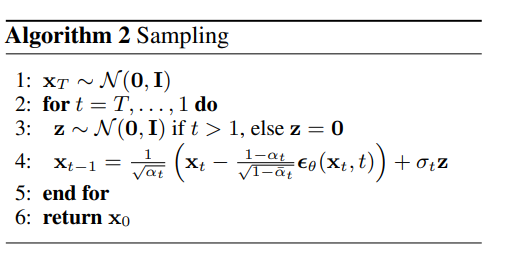

In [15]:
# Modified sample function to accept a specific model
@torch.no_grad()
def sample_ddpm(n_sample, model=nn_model): #
    model.eval()

    # x_T ~ N(0, 1), sample initial noise
    samples = torch.randn(n_sample, 1, height, height).to(device)

    for i in range(timesteps, 0, -1):
        print(f'Sampling step {i}', end='\r')
        t_idx = i - 1
        t_tensor = (torch.tensor([t_idx / timesteps])
                    .to(device)
                    .repeat(n_sample, 1)
                   )

        if i > 1:
            z = torch.randn_like(samples)
        else:
            z = torch.zeros_like(samples)

        # Use the passed 'model' instead of the global 'nn_model'
        pred_noise = model(samples, t_tensor, c=None)

        beta_t = b_t[t_idx]
        alpha_t = 1 - beta_t
        sqrt_one_minus_ab_t = torch.sqrt(1 - ab_t[t_idx])
        sigma_t = torch.sqrt(beta_t)

        samples = (1 / torch.sqrt(alpha_t)) * (samples - (beta_t / sqrt_one_minus_ab_t) * pred_noise) + sigma_t * z

    return samples

## Train Diffsion

Now that we have our 'diffusion model' defined, we need to train it to predict the noise given $x_t$ and $t$.

Starting Training Loop...
  Ep 0, Batch 0: Loss 0.9657
  Ep 0, Batch 200: Loss 0.0914
  Ep 0, Batch 400: Loss 0.0646
Epoch 0 Finished. Avg Loss: 0.09939
  --> New Best Model Saved! (Loss: 0.09939)
  Generating samples for Epoch 0...


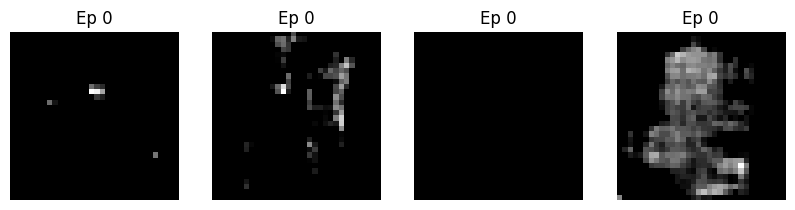

  Ep 1, Batch 0: Loss 0.0567
  Ep 1, Batch 200: Loss 0.0416
  Ep 1, Batch 400: Loss 0.0375
Epoch 1 Finished. Avg Loss: 0.05051
  --> New Best Model Saved! (Loss: 0.05051)
  Generating samples for Epoch 1...


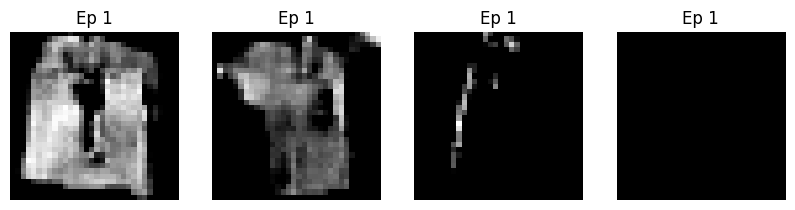

  Ep 2, Batch 0: Loss 0.0393
  Ep 2, Batch 200: Loss 0.0377
  Ep 2, Batch 400: Loss 0.0331
Epoch 2 Finished. Avg Loss: 0.04146
  --> New Best Model Saved! (Loss: 0.04146)
  Generating samples for Epoch 2...


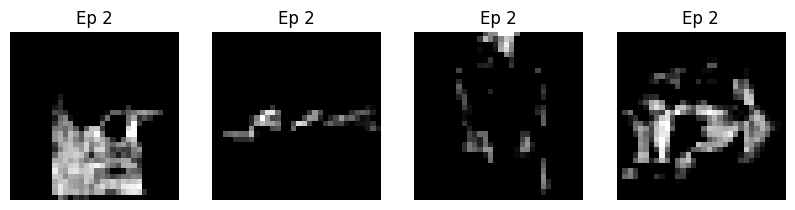

  Ep 3, Batch 0: Loss 0.0341
  Ep 3, Batch 200: Loss 0.0534
  Ep 3, Batch 400: Loss 0.0408
Epoch 3 Finished. Avg Loss: 0.03742
  --> New Best Model Saved! (Loss: 0.03742)
  Generating samples for Epoch 3...


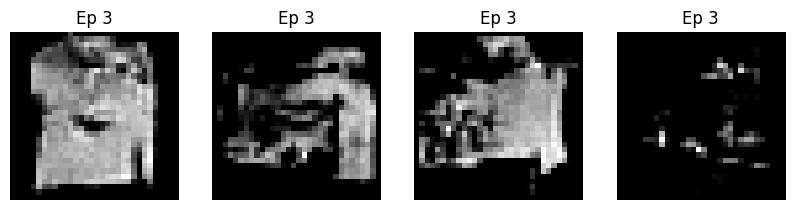

  Ep 4, Batch 0: Loss 0.0285
  Ep 4, Batch 200: Loss 0.0377
  Ep 4, Batch 400: Loss 0.0240
Epoch 4 Finished. Avg Loss: 0.03519
  --> New Best Model Saved! (Loss: 0.03519)
  Generating samples for Epoch 4...


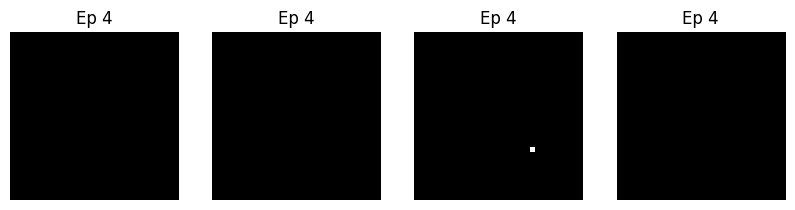

  Ep 5, Batch 0: Loss 0.0312
  Ep 5, Batch 200: Loss 0.0251
  Ep 5, Batch 400: Loss 0.0330
Epoch 5 Finished. Avg Loss: 0.03340
  --> New Best Model Saved! (Loss: 0.03340)
  Generating samples for Epoch 5...


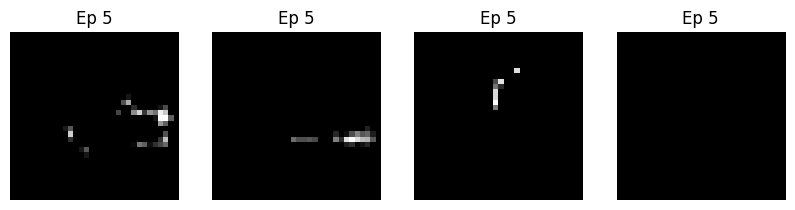

  Ep 6, Batch 0: Loss 0.0352
  Ep 6, Batch 200: Loss 0.0362
  Ep 6, Batch 400: Loss 0.0282
Epoch 6 Finished. Avg Loss: 0.03241
  --> New Best Model Saved! (Loss: 0.03241)
  Generating samples for Epoch 6...


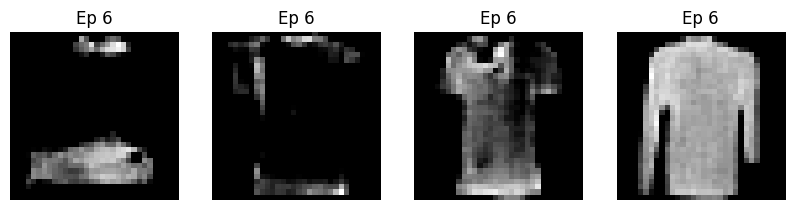

  Ep 7, Batch 0: Loss 0.0184
  Ep 7, Batch 200: Loss 0.0411
  Ep 7, Batch 400: Loss 0.0386
Epoch 7 Finished. Avg Loss: 0.03171
  --> New Best Model Saved! (Loss: 0.03171)
  Generating samples for Epoch 7...


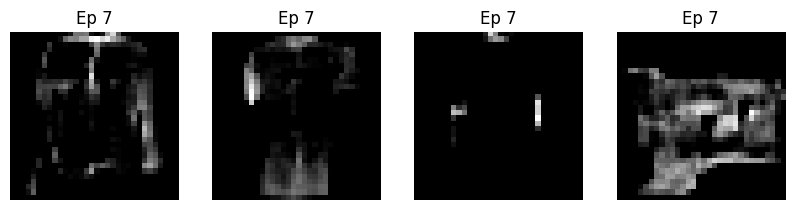

  Ep 8, Batch 0: Loss 0.0392
  Ep 8, Batch 200: Loss 0.0243
  Ep 8, Batch 400: Loss 0.0395
Epoch 8 Finished. Avg Loss: 0.03049
  --> New Best Model Saved! (Loss: 0.03049)
  Generating samples for Epoch 8...


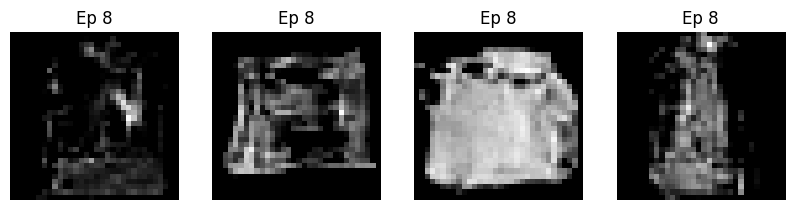

  Ep 9, Batch 0: Loss 0.0335
  Ep 9, Batch 200: Loss 0.0225
  Ep 9, Batch 400: Loss 0.0343
Epoch 9 Finished. Avg Loss: 0.03026
  --> New Best Model Saved! (Loss: 0.03026)
  Generating samples for Epoch 9...


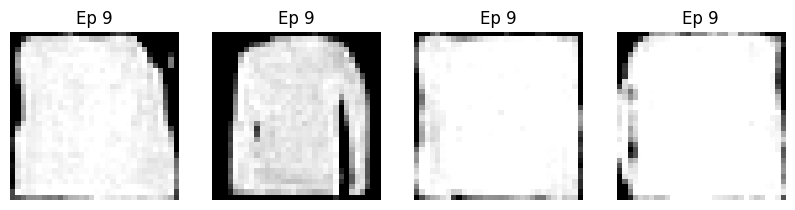

  Ep 10, Batch 0: Loss 0.0285
  Ep 10, Batch 200: Loss 0.0269
  Ep 10, Batch 400: Loss 0.0272
Epoch 10 Finished. Avg Loss: 0.02974
  --> New Best Model Saved! (Loss: 0.02974)
  Generating samples for Epoch 10...


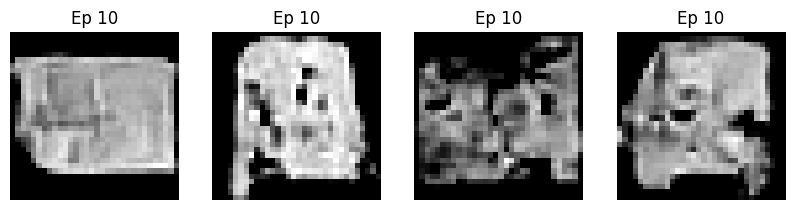

  Ep 11, Batch 0: Loss 0.0297
  Ep 11, Batch 200: Loss 0.0274
  Ep 11, Batch 400: Loss 0.0240
Epoch 11 Finished. Avg Loss: 0.02890
  --> New Best Model Saved! (Loss: 0.02890)
  Generating samples for Epoch 11...


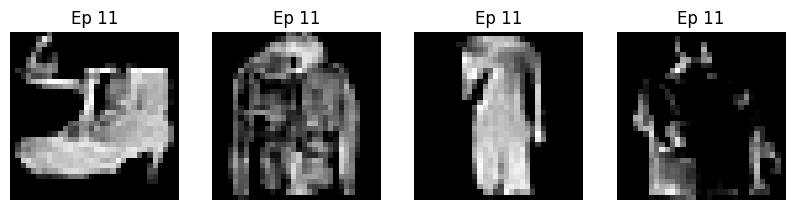

  Ep 12, Batch 0: Loss 0.0254
  Ep 12, Batch 200: Loss 0.0317
  Ep 12, Batch 400: Loss 0.0257
Epoch 12 Finished. Avg Loss: 0.02863
  --> New Best Model Saved! (Loss: 0.02863)
  Generating samples for Epoch 12...


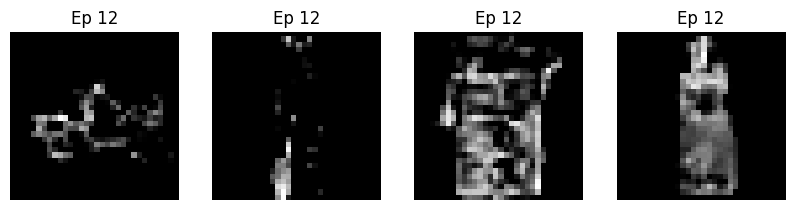

  Ep 13, Batch 0: Loss 0.0272
  Ep 13, Batch 200: Loss 0.0291
  Ep 13, Batch 400: Loss 0.0274
Epoch 13 Finished. Avg Loss: 0.02818
  --> New Best Model Saved! (Loss: 0.02818)
  Generating samples for Epoch 13...


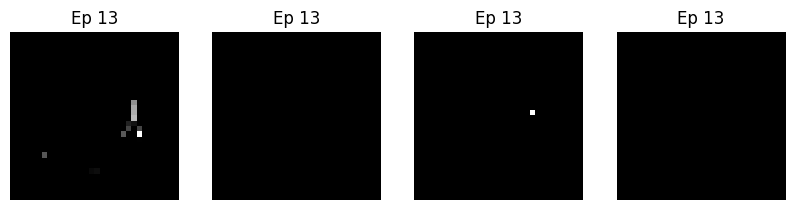

  Ep 14, Batch 0: Loss 0.0287
  Ep 14, Batch 200: Loss 0.0199
  Ep 14, Batch 400: Loss 0.0256
Epoch 14 Finished. Avg Loss: 0.02820
  Generating samples for Epoch 14...


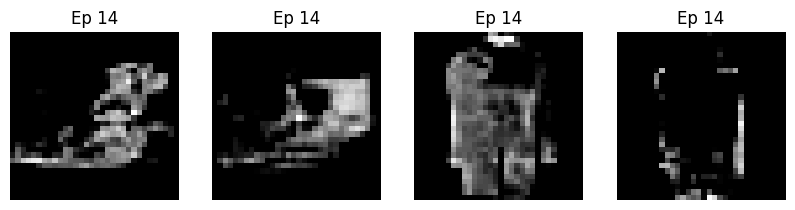

  Ep 15, Batch 0: Loss 0.0283
  Ep 15, Batch 200: Loss 0.0353
  Ep 15, Batch 400: Loss 0.0372
Epoch 15 Finished. Avg Loss: 0.02760
  --> New Best Model Saved! (Loss: 0.02760)
  Generating samples for Epoch 15...


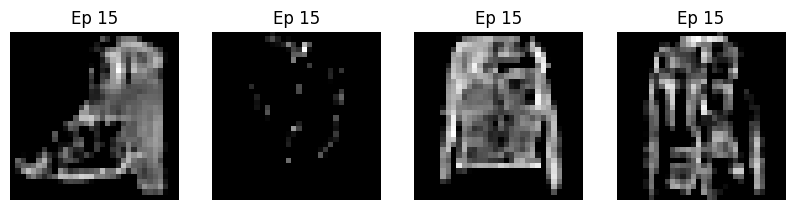

  Ep 16, Batch 0: Loss 0.0233
  Ep 16, Batch 200: Loss 0.0256
  Ep 16, Batch 400: Loss 0.0332
Epoch 16 Finished. Avg Loss: 0.02722
  --> New Best Model Saved! (Loss: 0.02722)
  Generating samples for Epoch 16...


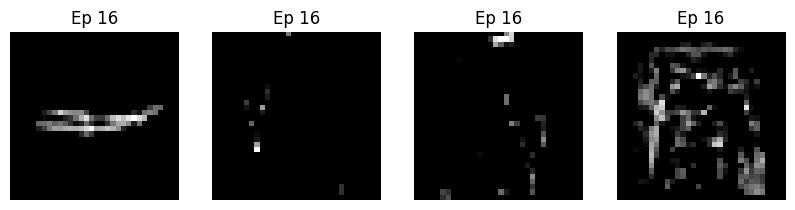

  Ep 17, Batch 0: Loss 0.0352
  Ep 17, Batch 200: Loss 0.0233
  Ep 17, Batch 400: Loss 0.0308
Epoch 17 Finished. Avg Loss: 0.02736
  Generating samples for Epoch 17...


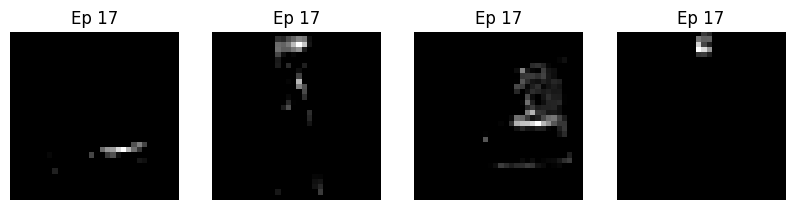

  Ep 18, Batch 0: Loss 0.0282
  Ep 18, Batch 200: Loss 0.0226
  Ep 18, Batch 400: Loss 0.0343
Epoch 18 Finished. Avg Loss: 0.02733
  Generating samples for Epoch 18...


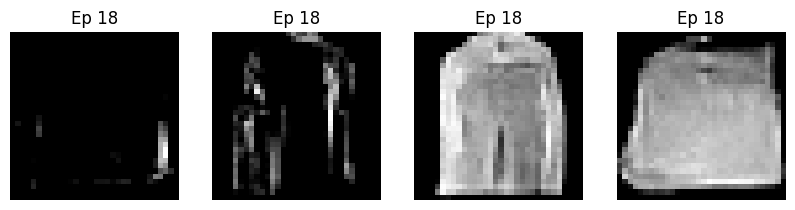

  Ep 19, Batch 0: Loss 0.0276
  Ep 19, Batch 200: Loss 0.0205
  Ep 19, Batch 400: Loss 0.0242
Epoch 19 Finished. Avg Loss: 0.02704
  --> New Best Model Saved! (Loss: 0.02704)
  Generating samples for Epoch 19...


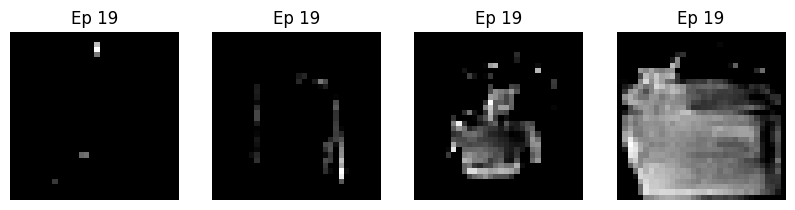

  Ep 20, Batch 0: Loss 0.0243
  Ep 20, Batch 200: Loss 0.0288
  Ep 20, Batch 400: Loss 0.0268
Epoch 20 Finished. Avg Loss: 0.02633
  --> New Best Model Saved! (Loss: 0.02633)
  Generating samples for Epoch 20...


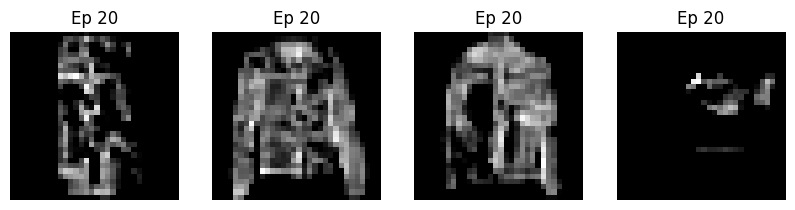

  Ep 21, Batch 0: Loss 0.0319
  Ep 21, Batch 200: Loss 0.0325
  Ep 21, Batch 400: Loss 0.0255
Epoch 21 Finished. Avg Loss: 0.02641
  Generating samples for Epoch 21...


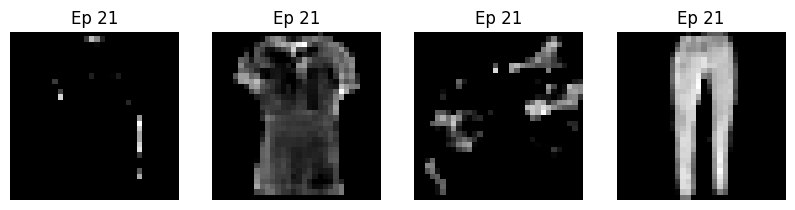

  Ep 22, Batch 0: Loss 0.0244
  Ep 22, Batch 200: Loss 0.0235
  Ep 22, Batch 400: Loss 0.0178
Epoch 22 Finished. Avg Loss: 0.02621
  --> New Best Model Saved! (Loss: 0.02621)
  Generating samples for Epoch 22...


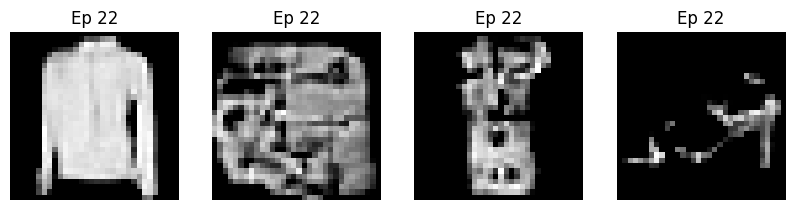

  Ep 23, Batch 0: Loss 0.0271
  Ep 23, Batch 200: Loss 0.0219
  Ep 23, Batch 400: Loss 0.0222
Epoch 23 Finished. Avg Loss: 0.02609
  --> New Best Model Saved! (Loss: 0.02609)
  Generating samples for Epoch 23...


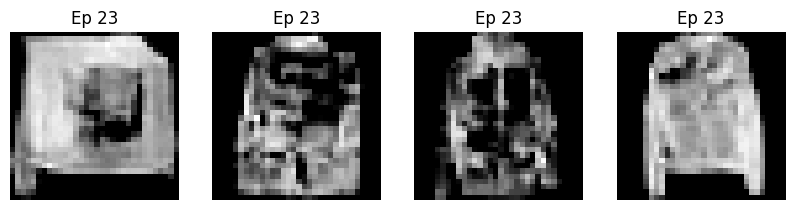

  Ep 24, Batch 0: Loss 0.0289
  Ep 24, Batch 200: Loss 0.0234
  Ep 24, Batch 400: Loss 0.0306
Epoch 24 Finished. Avg Loss: 0.02584
  --> New Best Model Saved! (Loss: 0.02584)
  Generating samples for Epoch 24...


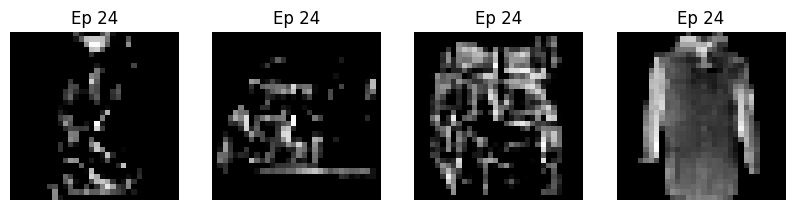

  Ep 25, Batch 0: Loss 0.0206
  Ep 25, Batch 200: Loss 0.0233
  Ep 25, Batch 400: Loss 0.0227
Epoch 25 Finished. Avg Loss: 0.02599
  Generating samples for Epoch 25...


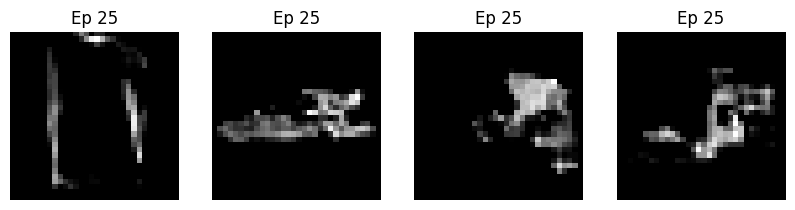

  Ep 26, Batch 0: Loss 0.0250
  Ep 26, Batch 200: Loss 0.0301
  Ep 26, Batch 400: Loss 0.0277
Epoch 26 Finished. Avg Loss: 0.02549
  --> New Best Model Saved! (Loss: 0.02549)
  Generating samples for Epoch 26...


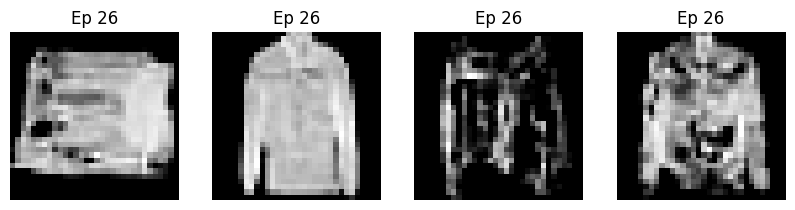

  Ep 27, Batch 0: Loss 0.0289
  Ep 27, Batch 200: Loss 0.0263
  Ep 27, Batch 400: Loss 0.0272
Epoch 27 Finished. Avg Loss: 0.02599
  Generating samples for Epoch 27...


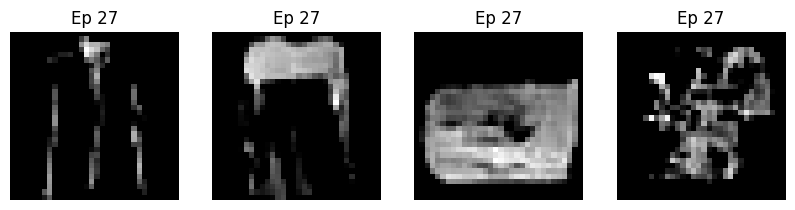

  Ep 28, Batch 0: Loss 0.0194
  Ep 28, Batch 200: Loss 0.0214
  Ep 28, Batch 400: Loss 0.0309
Epoch 28 Finished. Avg Loss: 0.02531
  --> New Best Model Saved! (Loss: 0.02531)
  Generating samples for Epoch 28...


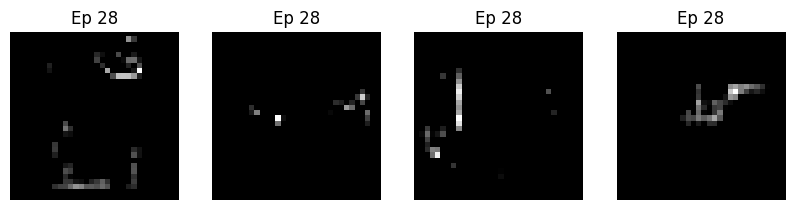

  Ep 29, Batch 0: Loss 0.0204
  Ep 29, Batch 200: Loss 0.0159
  Ep 29, Batch 400: Loss 0.0334
Epoch 29 Finished. Avg Loss: 0.02553
  Generating samples for Epoch 29...


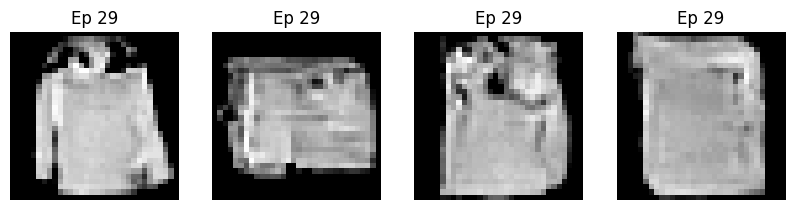

  Ep 30, Batch 0: Loss 0.0181
  Ep 30, Batch 200: Loss 0.0283
  Ep 30, Batch 400: Loss 0.0255
Epoch 30 Finished. Avg Loss: 0.02537
  Generating samples for Epoch 30...


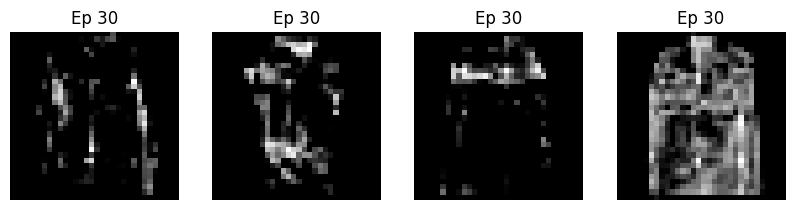

  Ep 31, Batch 0: Loss 0.0203
  Ep 31, Batch 200: Loss 0.0320
  Ep 31, Batch 400: Loss 0.0201
Epoch 31 Finished. Avg Loss: 0.02516
  --> New Best Model Saved! (Loss: 0.02516)
  Generating samples for Epoch 31...


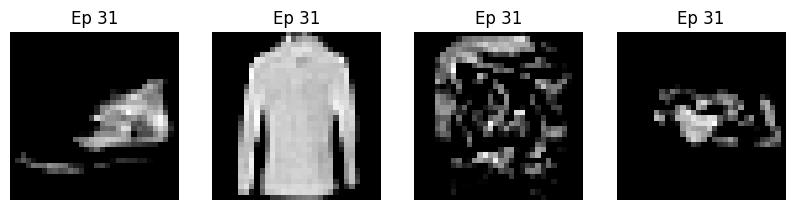

  Ep 32, Batch 0: Loss 0.0237
  Ep 32, Batch 200: Loss 0.0273
  Ep 32, Batch 400: Loss 0.0250
Epoch 32 Finished. Avg Loss: 0.02490
  --> New Best Model Saved! (Loss: 0.02490)
  Generating samples for Epoch 32...


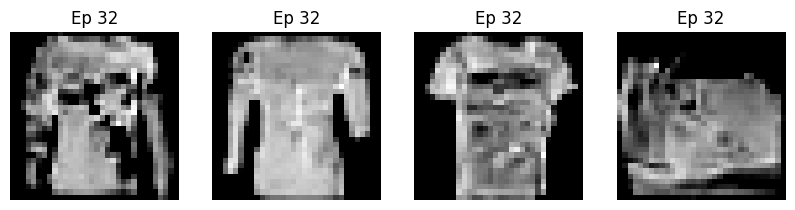

  Ep 33, Batch 0: Loss 0.0309
  Ep 33, Batch 200: Loss 0.0208
  Ep 33, Batch 400: Loss 0.0258
Epoch 33 Finished. Avg Loss: 0.02483
  --> New Best Model Saved! (Loss: 0.02483)
  Generating samples for Epoch 33...


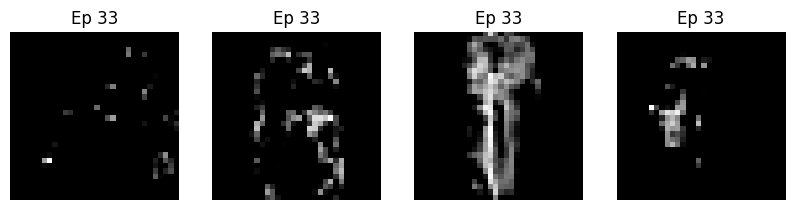

  Ep 34, Batch 0: Loss 0.0276
  Ep 34, Batch 200: Loss 0.0218
  Ep 34, Batch 400: Loss 0.0220
Epoch 34 Finished. Avg Loss: 0.02487
  Generating samples for Epoch 34...


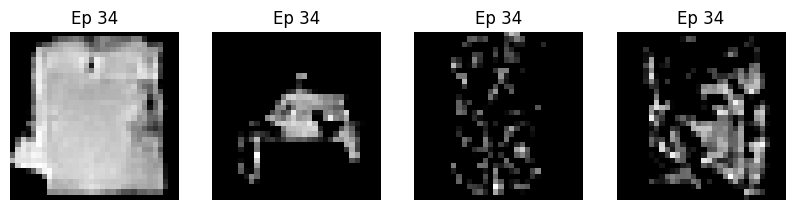

  Ep 35, Batch 0: Loss 0.0285
  Ep 35, Batch 200: Loss 0.0237
  Ep 35, Batch 400: Loss 0.0212
Epoch 35 Finished. Avg Loss: 0.02493
  Generating samples for Epoch 35...


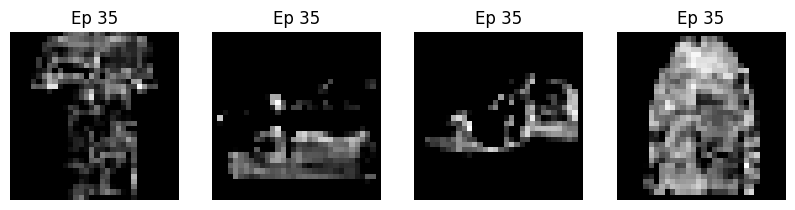

  Ep 36, Batch 0: Loss 0.0229
  Ep 36, Batch 200: Loss 0.0233
  Ep 36, Batch 400: Loss 0.0342
Epoch 36 Finished. Avg Loss: 0.02472
  --> New Best Model Saved! (Loss: 0.02472)
  Generating samples for Epoch 36...


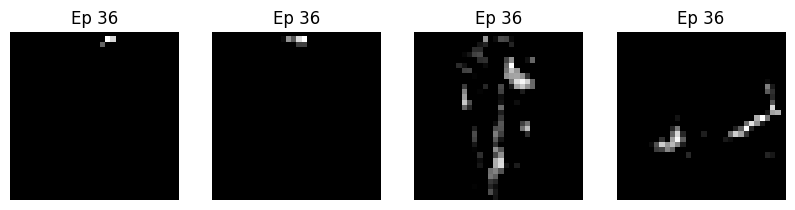

  Ep 37, Batch 0: Loss 0.0296
  Ep 37, Batch 200: Loss 0.0261
  Ep 37, Batch 400: Loss 0.0174
Epoch 37 Finished. Avg Loss: 0.02407
  --> New Best Model Saved! (Loss: 0.02407)
  Generating samples for Epoch 37...


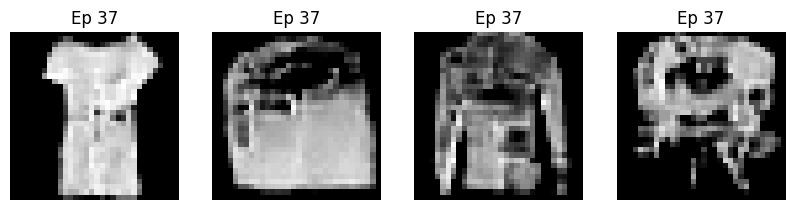

  Ep 38, Batch 0: Loss 0.0263
  Ep 38, Batch 200: Loss 0.0258
  Ep 38, Batch 400: Loss 0.0222
Epoch 38 Finished. Avg Loss: 0.02494
  Generating samples for Epoch 38...


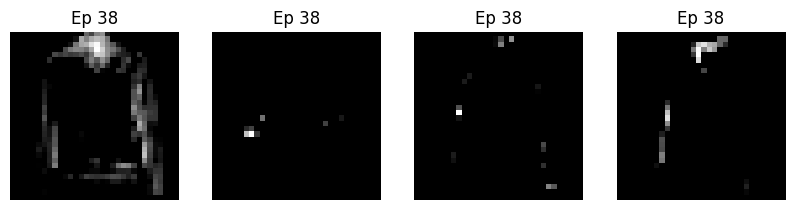

  Ep 39, Batch 0: Loss 0.0246
  Ep 39, Batch 200: Loss 0.0241
  Ep 39, Batch 400: Loss 0.0191
Epoch 39 Finished. Avg Loss: 0.02483
  Generating samples for Epoch 39...


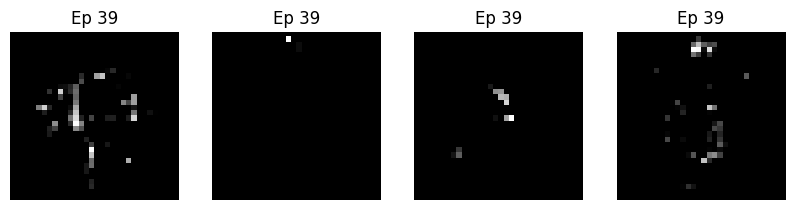

Training Complete!


In [30]:
# 1. Setup lists and variables
loss_history = []
min_loss = float('inf')

# Ensure model is in training mode initially
nn_model.train()

print("Starting Training Loop...")

for ep in range(n_epoch):
    # Set model to train mode (important because sampling sets it to eval)
    nn_model.train()

    epoch_loss = 0

    # --- Training Batch Loop ---
    for batch_idx, (x, _) in enumerate(train_dataloader):
        # Move data to device
        x = x.to(device)

        # Zero gradients
        optim.zero_grad()

        # Random timesteps for each image in batch
        t = torch.randint(0, timesteps, (x.shape[0],)).to(device)

        # Add noise (Forward Process)
        x_t, noise = perturb_input(x, t)

        # Predict noise (Reverse Process)
        # Normalize t to [0, 1] range
        pred_noise = nn_model(x_t, t.float() / timesteps, c=None)

        # Calculate Loss (MSE between actual noise and predicted noise)
        loss = F.mse_loss(pred_noise, noise)

        # Backpropagation
        loss.backward()
        optim.step()

        # Accumulate loss
        epoch_loss += loss.item()

        if batch_idx % 200 == 0:
            print(f"  Ep {ep}, Batch {batch_idx}: Loss {loss.item():.4f}")

    # --- End of Epoch Operations ---

    # 1. Calculate Average Loss
    avg_loss = epoch_loss / len(train_dataloader)
    loss_history.append(avg_loss)

    scheduler.step()
    print(f'Epoch {ep} Finished. Avg Loss: {avg_loss:.5f}')

    # 2. Save "Last" Model (Always overwrite)
    torch.save(nn_model.state_dict(), save_dir + "last_model.pth")

    # 3. Save "Best" Model (Only if improved)
    if avg_loss < min_loss:
        min_loss = avg_loss
        torch.save(nn_model.state_dict(), save_dir + "best_model.pth")
        print(f"  --> New Best Model Saved! (Loss: {min_loss:.5f})")

    # 4. Generate & Visualize Samples (Sanity Check)
    print(f"  Generating samples for Epoch {ep}...")
    # Generate only 4 samples to be fast
    with torch.no_grad():
        current_samples = sample_ddpm(n_sample=4, model=nn_model)

        # Plotting
        fig, axes = plt.subplots(1, 4, figsize=(10, 3))
        for i, ax in enumerate(axes):
            img = current_samples[i].detach().cpu().squeeze()
            # Clamp between 0 and 1 for correct display if values are out of range
            img = torch.clamp(img, 0, 1)
            ax.imshow(img, cmap='gray')
            ax.axis('off')
            ax.set_title(f"Ep {ep}")
        plt.show()

print("Training Complete!")

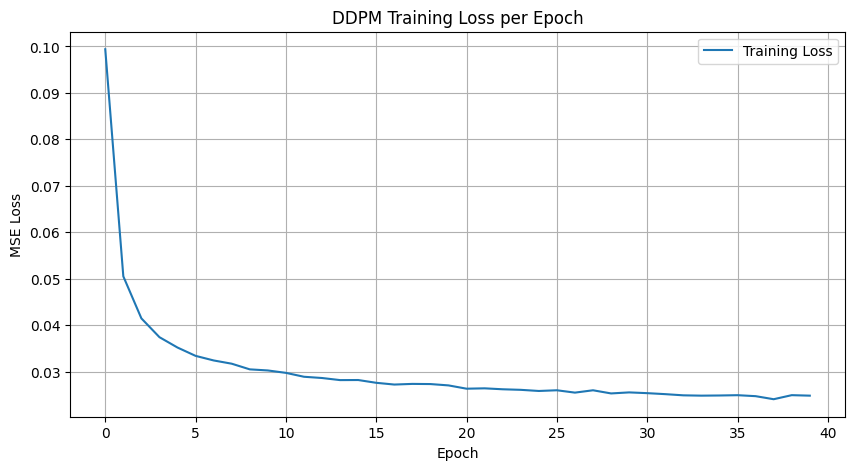

In [31]:
# Plotting the training loss curve
plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Training Loss')
plt.title('DDPM Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.legend()
plt.show()

## DDIM Sampling

In [39]:
# sample quickly using DDIM
@torch.no_grad()
def sample_ddim(n_sample, n=100, model=nn_model):
    model.eval()

    # x_T ~ N(0, 1), sample initial noise
    samples = torch.randn(n_sample, 1, height, height).to(device)

    # Calculate step size based on n (e.g., 1000 // 20 = 50 steps to skip)
    step_size = timesteps // n

    # We iterate backwards, skipping steps: 1000 -> 950 -> 900 ... -> 50
    for i in range(timesteps, 0, -step_size):
        print(f'DDIM Sampling step {i}', end='\r')

        # Current timestep index (e.g., 999)
        t = i - 1

        # Previous timestep index (next step in reverse process, e.g., 949)
        t_prev = t - step_size

        # Create time tensor
        t_tensor = (torch.tensor([t / timesteps])
                    .to(device)
                    .repeat(n_sample, 1)
                   )

        # 1. Predict noise (epsilon_theta)
        pred_noise = model(samples, t_tensor, c=None)

        # 2. Get alpha_bar values
        # alpha_bar_t corresponds to current step
        alpha_bar_t = ab_t[t]

        # alpha_bar_t_prev corresponds to the next step
        # If t_prev < 0, it means we reached x_0 (clean image), so alpha_bar = 1
        if t_prev >= 0:
            alpha_bar_t_prev = ab_t[t_prev]
        else:
            alpha_bar_t_prev = torch.tensor(1.0).to(device)

        # 3. Compute predicted x_0 (clean image estimate)
        # Formula: (x_t - sqrt(1 - alpha_bar_t) * eps) / sqrt(alpha_bar_t)
        # Note: We are NOT clamping this as per your request
        pred_x0 = (samples - torch.sqrt(1 - alpha_bar_t) * pred_noise) / torch.sqrt(alpha_bar_t)

        # 4. Calculate direction pointing to x_t (using predicted noise)
        # Formula: sqrt(1 - alpha_bar_t_prev) * eps
        dir_xt = torch.sqrt(1 - alpha_bar_t_prev) * pred_noise

        # 5. Update x_{t-1} (combine pred_x0 and direction)
        # Formula: sqrt(alpha_bar_t_prev) * pred_x0 + dir_xt
        samples = torch.sqrt(alpha_bar_t_prev) * pred_x0 + dir_xt

    return samples

## Results

Best model loaded.
Last model loaded.

SCENARIO 1: Best Model with DDPM (Standard)


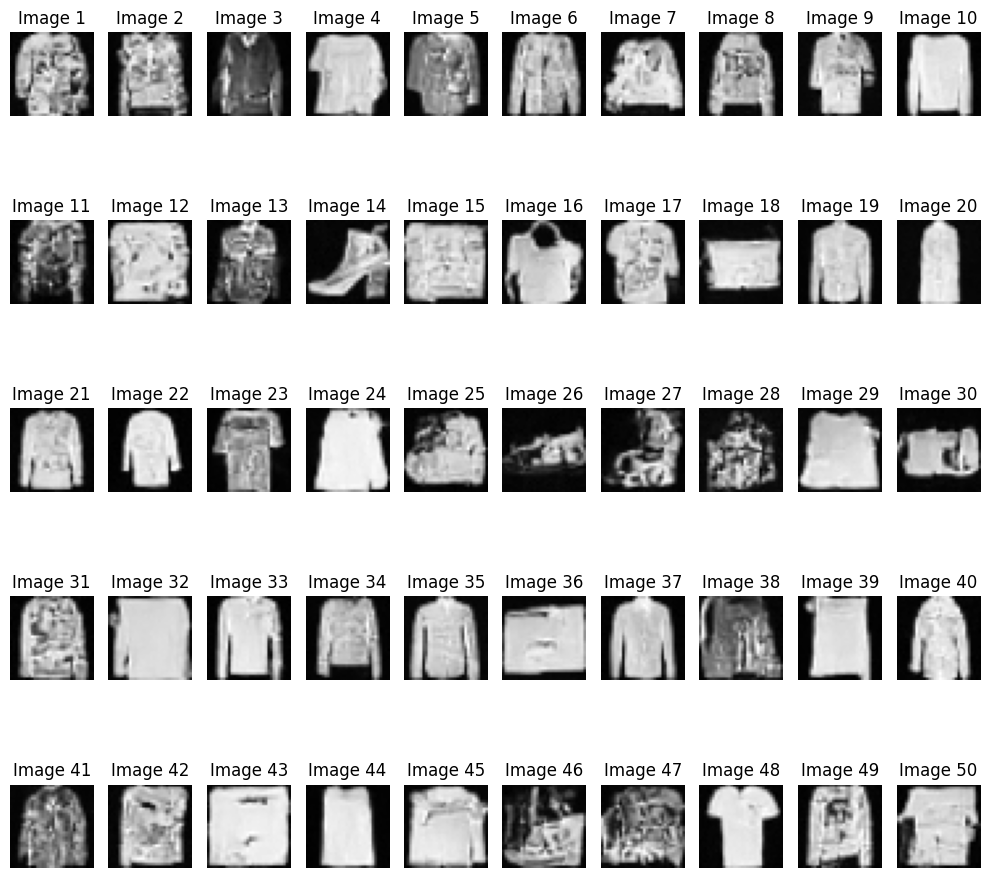


SCENARIO 2: Best Model with DDIM (Fast - 100 Steps)


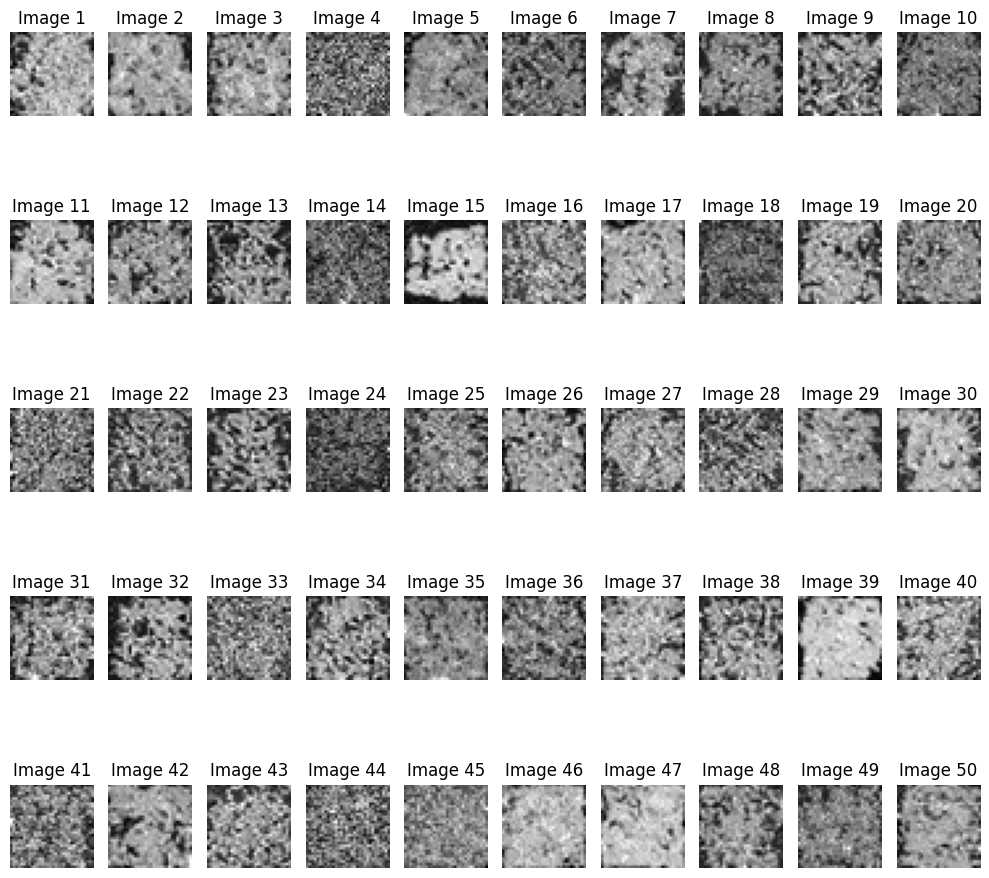


SCENARIO 3: Last Model with DDPM (Standard)


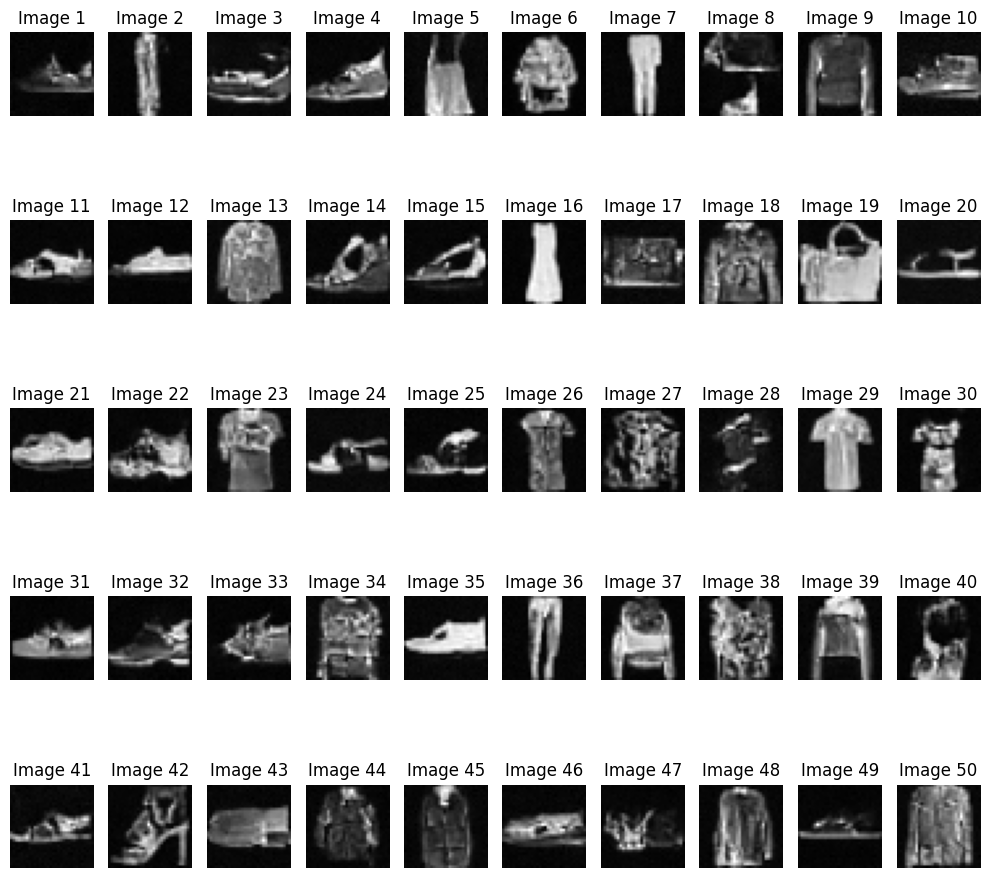


SCENARIO 4: Last Model with DDIM (Fast - 100 Steps)


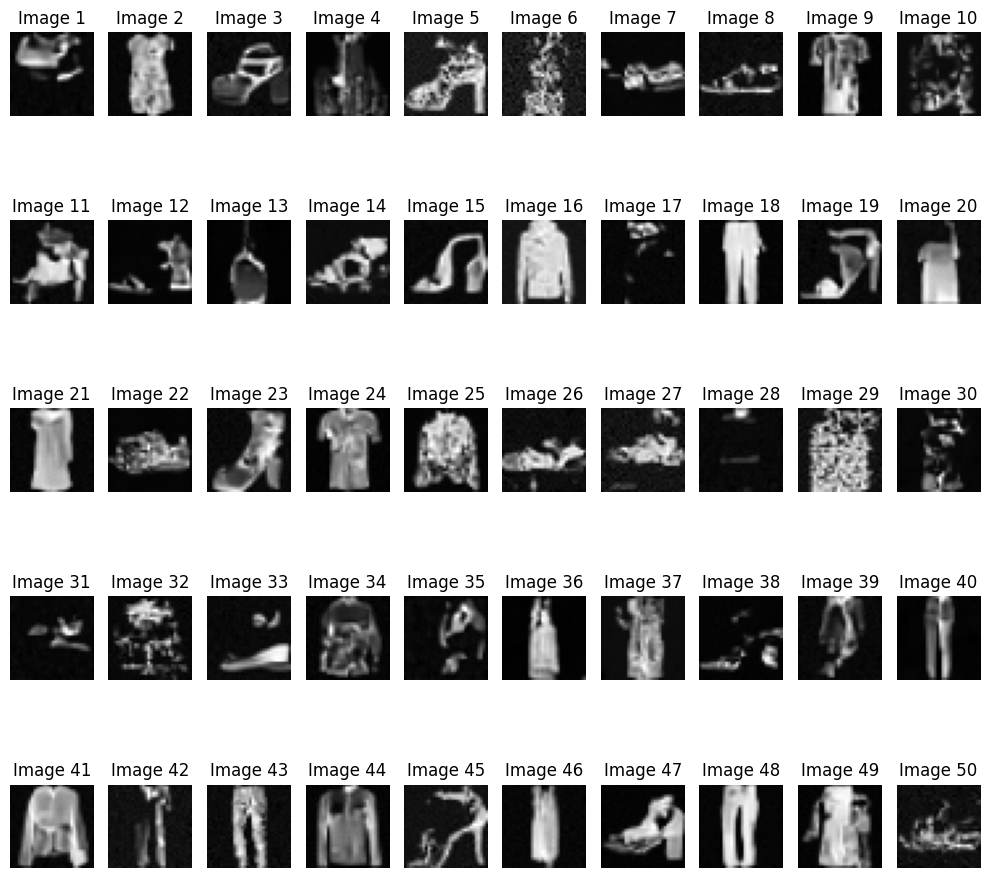

In [40]:
# Load BEST Model
best_model = Unet(in_channels=1, n_feat=n_feat, n_cfeat=n_cfeat, height=height).to(device)
best_model.load_state_dict(torch.load(save_dir + "best_model.pth", map_location=device))
best_model.eval()
print("Best model loaded.")

# Load LAST Model
last_model = Unet(in_channels=1, n_feat=n_feat, n_cfeat=n_cfeat, height=height).to(device)
last_model.load_state_dict(torch.load(save_dir + "last_model.pth", map_location=device))
last_model.eval()
print("Last model loaded.")

# 3. Define Sampling Parameters
n_sample = 50
nrows = 5  # Display in a single row

print("\n" + "="*40)
print("SCENARIO 1: Best Model with DDPM (Standard)")
print("="*40)
# Note: This might take longer (1000 steps)
samples_best_ddpm = sample_ddpm(n_sample, model=best_model)
plot_sample(samples_best_ddpm, n_sample, nrows)

print("\n" + "="*40)
print("SCENARIO 2: Best Model with DDIM (Fast - 100 Steps)")
print("="*40)
# Note: This is fast (100 steps)
samples_best_ddim = sample_ddim(n_sample, n=100, model=best_model)
plot_sample(samples_best_ddim, n_sample, nrows)

print("\n" + "="*40)
print("SCENARIO 3: Last Model with DDPM (Standard)")
print("="*40)
samples_last_ddpm = sample_ddpm(n_sample, model=last_model)
plot_sample(samples_last_ddpm, n_sample, nrows)

print("\n" + "="*40)
print("SCENARIO 4: Last Model with DDIM (Fast - 100 Steps)")
print("="*40)
samples_last_ddim = sample_ddim(n_sample, n=100, model=last_model)
plot_sample(samples_last_ddim, n_sample, nrows)

# Compare DDIM and DDPM Time

In [41]:
%timeit -r 1 sample_ddim(50,n=100,model=best_model)
%timeit -r 1 sample_ddpm(50,model=best_model)

2.03 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
20.6 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


# Evaluating the Generated Samples:

In [29]:
!pip install torchmetrics
!pip install torch-fidelity

In [42]:
from torchmetrics.image.fid import FrechetInceptionDistance
import torch

# 1. Define Preprocessing for FID (Convert [-1,1] 1-channel to [0,255] 3-channels)
def preprocess_for_fid(images):
    """
    Converts images from [-1, 1] range with 1 channel to [0, 255] range with 3 channels.
    Required for InceptionV3 input.
    """
    # 1. Denormalize to [0, 1]
    images = (images.clamp(-1, 1) + 1) / 2

    # 2. Scale to [0, 255] and convert to byte (uint8)
    images = (images * 255).to(torch.uint8)

    # 3. Repeat channel to make it 3-channel (B, 1, H, W) -> (B, 3, H, W)
    if images.shape[1] == 1:
        images = images.repeat(1, 3, 1, 1)

    return images

# 2. Define the FID Calculation Function
def calculate_fid_score(model, sample_method, method_name, n_samples=500, batch_size=100):
    print(f"\n--- Calculating FID for {method_name} ---")

    # Initialize FID metric
    # feature=64 is often used for small datasets/images to avoid dimensionality issues,
    # but 2048 is standard. Let's use 2048 (default).
    fid = FrechetInceptionDistance(feature=2048).to(device)

    # A. Add REAL images from validation set
    print("Processing Real Images...", end=" ")
    real_count = 0
    for x, _ in val_dataloader:
        x = x.to(device)
        x_proc = preprocess_for_fid(x)
        fid.update(x_proc, real=True)
        real_count += x.shape[0]
        if real_count >= n_samples:
            break
    print("Done.")

    # B. Generate and Add FAKE images
    print("Generating Fake Images...", end=" ")
    model.eval()

    # Loop to generate in batches to avoid OOM
    num_batches = n_sample // batch_size
    if n_sample % batch_size != 0: num_batches += 1

    generated_count = 0

    for _ in range(num_batches):
        # Determine current batch size
        current_batch = min(batch_size, n_samples - generated_count)

        # Generate samples based on method
        if sample_method == 'ddpm':
            # Note: We suppress print inside loop to keep output clean
            fake_imgs = sample_ddpm(current_batch, model=model)
        else: # ddim
            fake_imgs = sample_ddim(current_batch, n=100, model=model)

        # Preprocess and Update FID
        fake_imgs_proc = preprocess_for_fid(fake_imgs)
        fid.update(fake_imgs_proc, real=False)

        generated_count += current_batch
        print(f"{generated_count}/{n_samples}", end=".. ")

    print("Done.")

    # C. Compute Score
    print("Computing FID Score...")
    score = fid.compute()
    print(f"FID Score for {method_name}: {score.item():.4f}")
    return score.item()

# ==========================================
# Run Comparisons
# ==========================================

# Settings: Increase n_samples to 1000 or 2000 for more accurate results
# For quick testing, 200-500 is enough.
N_SAMPLES_FID = 200
BATCH_SIZE_GEN = 50 # Generate 50 at a time to be safe

results = {}

# 1. Best Model + DDPM
results['Best_DDPM'] = calculate_fid_score(best_model, 'ddpm', 'Best Model (DDPM)', N_SAMPLES_FID, BATCH_SIZE_GEN)

# 2. Best Model + DDIM
results['Best_DDIM'] = calculate_fid_score(best_model, 'ddim', 'Best Model (DDIM)', N_SAMPLES_FID, BATCH_SIZE_GEN)

# 3. Last Model + DDPM
results['Last_DDPM'] = calculate_fid_score(last_model, 'ddpm', 'Last Model (DDPM)', N_SAMPLES_FID, BATCH_SIZE_GEN)

# 4. Last Model + DDIM
results['Last_DDIM'] = calculate_fid_score(last_model, 'ddim', 'Last Model (DDIM)', N_SAMPLES_FID, BATCH_SIZE_GEN)

# Print Summary
print("\n" + "="*30)
print("FINAL FID COMPARISON")
print("="*30)
for name, score in results.items():
    print(f"{name}: {score:.4f}")


--- Calculating FID for Best Model (DDPM) ---
Processing Real Images... Done.
50/200.. Done.
Computing FID Score...
FID Score for Best Model (DDPM): 169.8301

--- Calculating FID for Best Model (DDIM) ---
Processing Real Images... Done.
50/200.. Done.
Computing FID Score...
FID Score for Best Model (DDIM): 313.3063

--- Calculating FID for Last Model (DDPM) ---
Processing Real Images... Done.
50/200.. Done.
Computing FID Score...
FID Score for Last Model (DDPM): 146.7604

--- Calculating FID for Last Model (DDIM) ---
Processing Real Images... Done.
50/200.. Done.
Computing FID Score...
FID Score for Last Model (DDIM): 179.2615

FINAL FID COMPARISON
Best_DDPM: 169.8301
Best_DDIM: 313.3063
Last_DDPM: 146.7604
Last_DDIM: 179.2615
